# Medial field head — bunny overfit (auto-supervised)

Fine-tune a **new medial head** on frozen Points2Surf features. Losses follow the MAT-style medial constraints (no medial GT):

- **Maximality:** `ReLU(|φ| − M)²` — medial radius ≥ distance to surface
- **Inscription:** `(|φ(c)| − M)²` with center projection `c`
- **Orthogonality:** `(∇M · ∇φ)²`
- Plus **Eikonal** and **surface regularizer** on the frozen SDF branch

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.utils.data as data
import trimesh
import trimesh.transformations as trafo
from tqdm import tqdm

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'source').is_dir():
    raise RuntimeError('Run from points2surf repo root.')
sys.path.insert(0, str(REPO_ROOT))

from source import data_loader, sdf, points_to_surf_eval
from source import medial_field, points_to_surf_medial
from source.base.utils import torch_load
import importlib
importlib.reload(medial_field)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda:0


## Configuration

In [2]:
SHAPE_NAME = 'bunny'
BUNNY_OBJ = REPO_ROOT / 'data' / 'bunny.obj'
DATASET_DIR = REPO_ROOT / 'datasets' / 'bunny_medial'
OUT_DIR = REPO_ROOT / 'models' / 'bunny_medial_overfit'

MODEL_NAME = 'p2s_vanilla'
MODEL_POSTFIX = '_model_149.pth'
PARAM_POSTFIX = '_params.pth'
MODEL_DIR = REPO_ROOT / 'models'

NUM_QUERY_PTS = 2000
NUM_POINTS = 50000
BATCH_SIZE = 8                # smaller: inscription = 2x with_mf_grad per step
NEPOCH = 3
LR = 1e-3

LOSS_WEIGHTS = medial_field.get_default_weights()
# override examples:
# LOSS_WEIGHTS['maximality'] = 100.0
# LOSS_WEIGHTS['inscription'] = 500.0
# LOSS_WEIGHTS['orthogonality'] = 0.03

SLICE_GRID_RES = 128
SLICE_EPSILON = 20
INFER_BATCH = 64

## 1. Prepare bunny + query points

Query SDF files are only for the Points2Surf dataloader layout; **medial training ignores mesh GT** and uses predicted φ only.

In [3]:
def to_unit_cube(mesh):
    mesh = mesh.copy()
    c = (mesh.bounds[0] + mesh.bounds[1]) * 0.5
    mesh.apply_transform(trafo.translation_matrix(-c))
    mesh.apply_transform(trafo.scale_matrix(1.0 / mesh.extents.max()))
    return mesh

mesh_gt = to_unit_cube(trimesh.load(BUNNY_OBJ, force='mesh'))
pts = mesh_gt.vertices[:, :3].astype(np.float32)
if pts.shape[0] > NUM_POINTS:
    pts = pts[np.random.default_rng(42).choice(pts.shape[0], NUM_POINTS, replace=False)]

pts_dir = DATASET_DIR / '04_pts'
qpts_dir = DATASET_DIR / '05_query_pts'
qdist_dir = DATASET_DIR / '05_query_dist'
for d in (pts_dir, qpts_dir, qdist_dir):
    d.mkdir(parents=True, exist_ok=True)
np.save(pts_dir / f'{SHAPE_NAME}.xyz.npy', pts)
(DATASET_DIR / 'testset.txt').write_text(f'{SHAPE_NAME}\n')

rng = np.random.RandomState(42)
patch_radius = (1.0 + 3) / 128
query_pts = sdf.get_query_pts_for_mesh(mesh_gt, NUM_QUERY_PTS, patch_radius, far_query_pts_ratio=0.3, rng=rng)
# placeholder targets for dataloader (not used in medial losses)
query_sdf = np.zeros(len(query_pts), dtype=np.float32)

np.save(qpts_dir / f'{SHAPE_NAME}.ply.npy', query_pts.astype(np.float32))
np.save(qdist_dir / f'{SHAPE_NAME}.ply.npy', query_sdf)
print(f'Query points: {len(query_pts)}')

Query points: 2000


## 2. Dataset + frozen backbone + medial head

In [4]:
model_file = MODEL_DIR / f'{MODEL_NAME}{MODEL_POSTFIX}'
param_file = MODEL_DIR / f'{MODEL_NAME}{PARAM_POSTFIX}'
backbone, train_opt = points_to_surf_medial.load_pretrained_backbone(
    str(model_file), str(param_file), device)
print('Backbone outputs:', train_opt.outputs)

base_ds = data_loader.PointcloudPatchDataset(
    root=str(DATASET_DIR),
    shape_list_filename='testset.txt',
    points_per_patch=train_opt.points_per_patch,
    patch_radius=train_opt.patch_radius,
    patch_features=train_opt.outputs,
    seed=42,
    center=train_opt.patch_center,
    cache_capacity=1,
    pre_processed_patches=True,
    sub_sample_size=train_opt.sub_sample_size,
    reconstruction=False,
    epsilon=-1,
    uniform_subsample=getattr(train_opt, 'uniform_subsample', 0),
    fixed_subsample=getattr(train_opt, 'fixed_subsample', 0),
    num_workers=0,
)

ds = base_ds
loader = data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

model = points_to_surf_medial.PointsToSurfMedialModel(backbone).to(device)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'Trainable params (medial head): {trainable:,} | Frozen (backbone): {frozen:,}')

Backbone outputs: ['imp_surf_magnitude', 'imp_surf_sign', 'patch_pts_ids', 'p_index']
getting information for 1 shapes
Trainable params (medial head): 8,321 | Frozen (backbone): 6,167,814


## 3. Overfit medial head on bunny

In [5]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
history = {k: [] for k in ['Total', 'Maximality', 'Inscription', 'Orthogonality', 'Eikonal', 'Surface Regularizer']}

model.train()
for epoch in range(NEPOCH):
    epoch_loss = 0.0
    n_batches = 0
    last_parts = {}
    for batch in loader:
        for k in batch:
            batch[k] = batch[k].to(device)
        t = epoch / max(NEPOCH - 1, 1)
        loss, parts = medial_field.compute_medial_losses(
            model, batch, train_opt, weights=LOSS_WEIGHTS, t=t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
        last_parts = {k: float(v) for k, v in parts.items() if k != 'Total'}

    for k in history:
        if k == 'Total':
            history[k].append(epoch_loss / max(n_batches, 1))
        else:
            history[k].append(last_parts.get(k, 0.0))

    if epoch % 20 == 0 or epoch == NEPOCH - 1:
        print(f"epoch {epoch:4d}  total={history['Total'][-1]:.4f}  "
              f"max={history['Maximality'][-1]:.4f}  ins={history['Inscription'][-1]:.4f}  "
              f"orth={history['Orthogonality'][-1]:.4f}")

OUT_DIR.mkdir(parents=True, exist_ok=True)
torch.save(model.medial_head.state_dict(), OUT_DIR / 'medial_head.pth')
print('Saved', OUT_DIR / 'medial_head.pth')

epoch    0  total=11.4401  max=0.0000  ins=0.0006  orth=0.0003
epoch    2  total=3.5561  max=0.0000  ins=0.0004  orth=0.0144
Saved /home/martin/Desktop/points2surf/models/bunny_medial_overfit/medial_head.pth


## 4. Loss curves + auto-supervised constraint checks

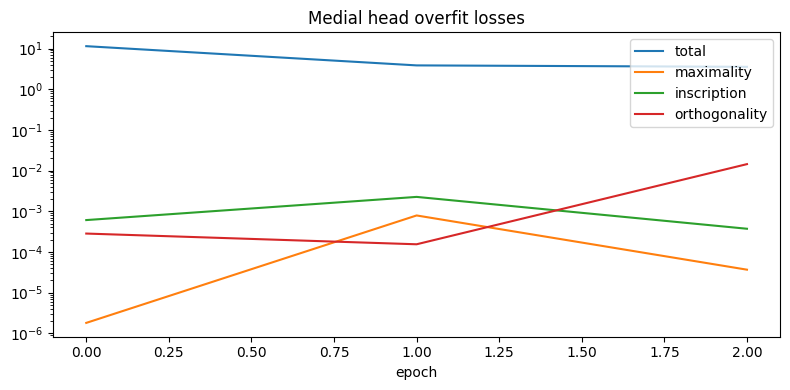

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for k in ['Total', 'Maximality', 'Inscription', 'Orthogonality']:
    ax.plot(history[k], label=k.lower())
ax.set_yscale('log')
ax.set_xlabel('epoch')
ax.legend()
ax.set_title('Medial head overfit losses')
plt.tight_layout()
plt.show()

model.eval()
M_list, phi_abs_list, dots = [], [], []
eval_loader = data.DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
with torch.enable_grad():
    for batch in eval_loader:
        for k in batch:
            batch[k] = batch[k].to(device)
        sdf, agrad, _, mf, mf_grad = model.with_mf_grad(batch, train_opt)
        inside = sdf < 0
        if inside.sum() == 0:
            continue
        M_list.append(mf[inside].detach().cpu().numpy())
        phi_abs_list.append(sdf[inside].abs().detach().cpu().numpy())
        dot = torch.sum(mf_grad * agrad, dim=-1)[inside]
        dots.append(dot.detach().cpu().numpy())

## 5. SDF & medial field slices (bunny)

Sparse grid-shell predictions splatted to a volume (same idea as `bunny_inference.ipynb`). Gray = no sample on that slice.

Grid query points for slices: 276,108
Running SDF + medial inference on grid (may take a few minutes)...
phi range: [-0.1726, 0.0976]
M  range: [0.0000, 0.3616]


/tmp/ipykernel_847281/1328190867.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


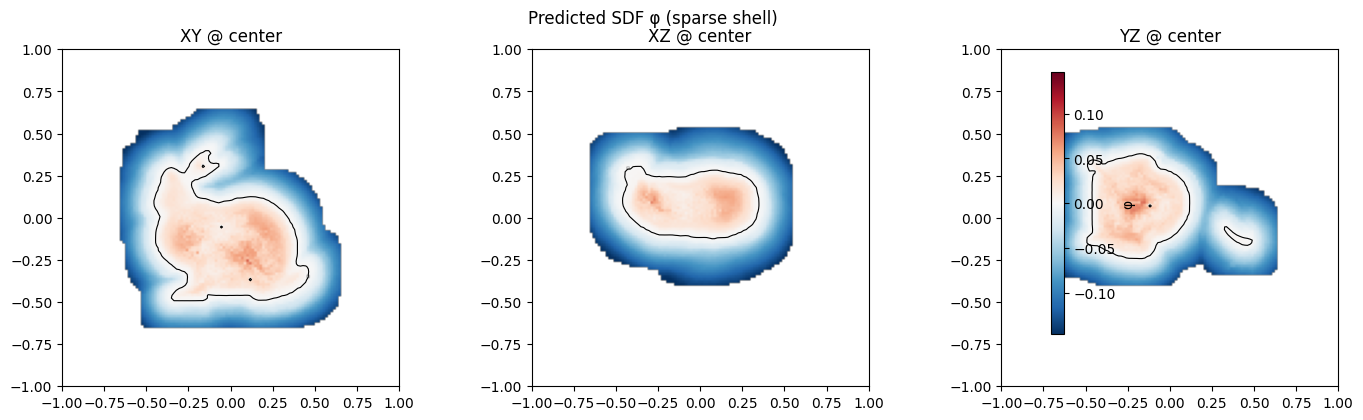

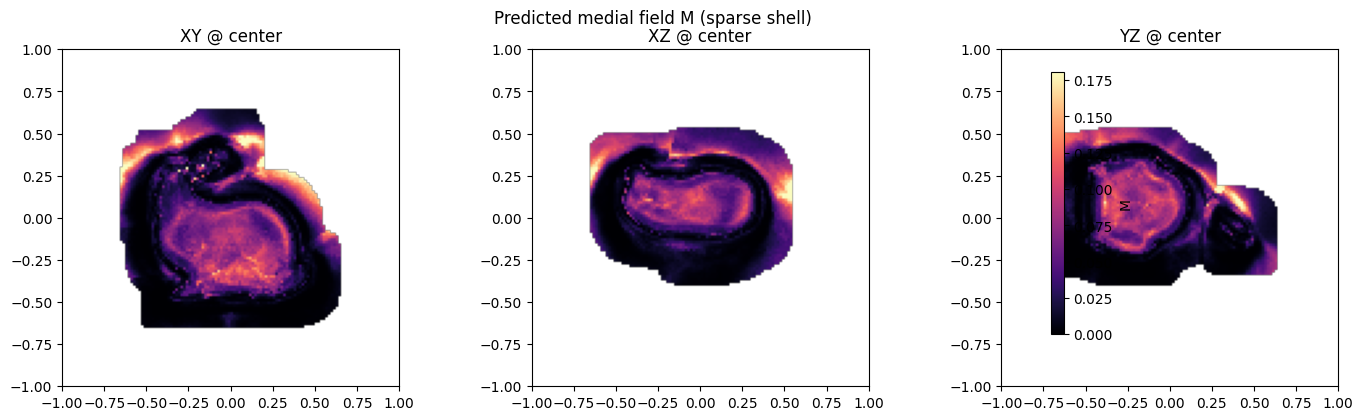

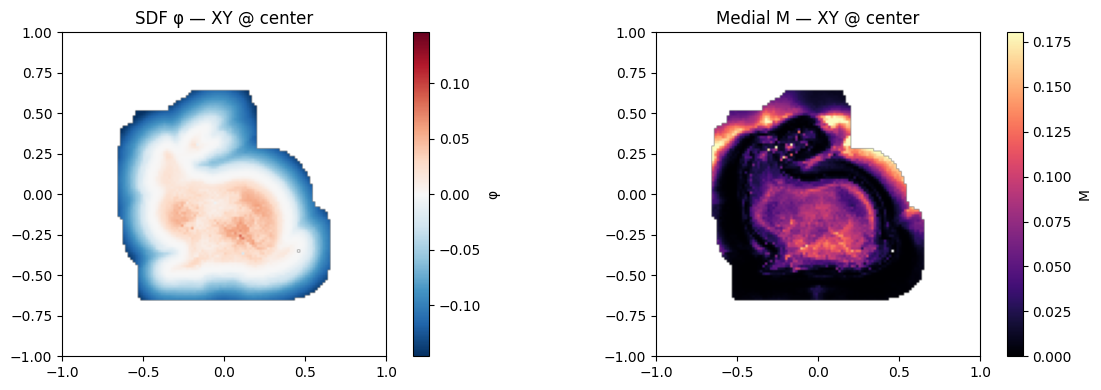

In [7]:
import importlib
importlib.reload(medial_field)

from source import sdf

grid_pts = sdf.get_voxel_centers_grid_smaller_pc(
    pts, grid_resolution=SLICE_GRID_RES, distance_threshold_vs=SLICE_EPSILON)
print(f'Grid query points for slices: {grid_pts.shape[0]:,}')

print('Running SDF + medial inference on grid (may take a few minutes)...')
phi_grid, med_grid = medial_field.predict_fields_on_queries(
    model, train_opt, grid_pts, pts, device, batch_size=INFER_BATCH)

volume_phi = np.zeros((SLICE_GRID_RES, SLICE_GRID_RES, SLICE_GRID_RES), dtype=np.float32)
volume_med = np.zeros((SLICE_GRID_RES, SLICE_GRID_RES, SLICE_GRID_RES), dtype=np.float32)
volume_phi = sdf.add_samples_to_volume(volume_phi, grid_pts, phi_grid)
volume_med = sdf.add_samples_to_volume(volume_med, grid_pts, med_grid)

print(f'phi range: [{phi_grid.min():.4f}, {phi_grid.max():.4f}]')
print(f'M  range: [{med_grid.min():.4f}, {med_grid.max():.4f}]')


def central_slices(vol):
    mid = SLICE_GRID_RES // 2
    return [('XY', vol[:, :, mid].T), ('XZ', vol[:, mid, :].T), ('YZ', vol[mid, :, :].T)]


def plot_field_slices(vol, title, vmin, vmax, cmap='RdBu_r', cbar_label='value', mask_zeros=True):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (plane, sl) in zip(axes, central_slices(vol)):
        sl_plot = np.ma.masked_where(np.abs(sl) < 1e-8, sl) if mask_zeros else sl
        im = ax.imshow(sl_plot, origin='lower', vmin=vmin, vmax=vmax,
                       extent=[-1, 1, -1, 1], aspect='equal', cmap=cmap)
        if mask_zeros and cmap == 'RdBu_r':
            try:
                ax.contour(np.asarray(sl), levels=[0], colors='k', linewidths=0.8,
                           extent=[-1, 1, -1, 1], origin='lower')
            except ValueError:
                pass
        ax.set_title(f'{plane} @ center')
    fig.colorbar(im, ax=axes, label=cbar_label, shrink=0.85)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


phi_max = np.percentile(np.abs(phi_grid), 99)
med_max = np.percentile(med_grid, 99)
plot_field_slices(volume_phi, 'Predicted SDF φ (sparse shell)',
                  vmin=-phi_max, vmax=phi_max, cmap='RdBu_r', cbar_label='φ')
plot_field_slices(volume_med, 'Predicted medial field M (sparse shell)',
                  vmin=0, vmax=med_max, cmap='magma', cbar_label='M', mask_zeros=True)

mid = SLICE_GRID_RES // 2
sl_phi = volume_phi[:, :, mid].T
sl_med = volume_med[:, :, mid].T
mask = np.abs(sl_phi) > 1e-8
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
im0 = ax[0].imshow(np.ma.masked_where(~mask, sl_phi), origin='lower', vmin=-phi_max, vmax=phi_max,
                   extent=[-1, 1, -1, 1], aspect='equal', cmap='RdBu_r')
im1 = ax[1].imshow(np.ma.masked_where(~mask, sl_med), origin='lower', vmin=0, vmax=med_max,
                   extent=[-1, 1, -1, 1], aspect='equal', cmap='magma')
ax[0].set_title('SDF φ — XY @ center')
ax[1].set_title('Medial M — XY @ center')
fig.colorbar(im0, ax=ax[0], label='φ')
fig.colorbar(im1, ax=ax[1], label='M')
plt.tight_layout()
plt.show()